In [26]:
import importlib
importlib.reload(data_prep)


<module 'data_prep' from '/Users/ehabhasan/Documents/Projects/Time Series Forecasting/Large Scale Forecasting/data_prep.py'>

In [ ]:
import pandas as pd
import data_prep  
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)        # Avoid line wrapping
pd.set_option('display.max_colwidth', None) # Show full content of each cell

In [18]:
# load the data
data_processed=pd.read_csv('Data/data.csv')
# make sure the hourly data processed correctly
data_processed['Date']=pd.to_datetime(data_processed['Date'],errors='coerce')
data_processed['Date'] = data_processed['Date'].dt.floor('h')

# Data Enrichment

In [19]:
# add is_holiday and is_weekend
data_processed=data_prep.add_features_per_country(data_processed,"CountryCode","Date")
data_processed.head()

,Date,CountryCode,Value,Temp_C,Humidity,WindSpeed,SolarRadiation,CloudCover,is_holiday,is_weekend
0,2023-01-01 00:00:00,AT,5280.8,4.2,77,13.0,0.0,82,1,1
1,2023-01-01 01:00:00,AT,5143.0,3.9,78,11.5,0.0,100,1,1
2,2023-01-01 02:00:00,AT,4958.7,3.7,76,11.6,0.0,100,1,1
3,2023-01-01 03:00:00,AT,4905.4,2.9,78,9.5,0.0,98,1,1
4,2023-01-01 04:00:00,AT,5025.8,1.8,83,6.9,0.0,100,1,1


# Label Encoding

- I will use label encoding for CountryCode to use it later in the embedding layer

An embedding layer is a special type of hidden layer that transforms a categorical value (like a country index) into a dense, learnable vector.

In [20]:
le=LabelEncoder()
data_processed['CountryLabel']=le.fit_transform(data_processed['CountryCode'])
data_featured=data_processed.drop(columns=['CountryCode'])
# Used later to map the labels to the country code
map_label_country=data_processed[['CountryCode','CountryLabel']].drop_duplicates().reset_index(drop=True)

# Data Splitting

- To prevent data leakage we will split the data first and then scale. 
- The data was split before the date transformation because we are using the date to split the data.

In [21]:
train,vald,test=data_prep.split_by_country(data_featured,"CountryLabel","Date")

In [22]:
print(len(train),len(vald),len(test))

315072 105984 51840


- This function performs a data quality (DQ) check to ensure that each country in the dataset has an equal number of records after splitting. This is crucial when evaluating time series models trained per country.

In [23]:
data_prep.split_by_country_check(test,"CountryLabel",24)

The function split the data correctly for 0
The function split the data correctly for 1
The function split the data correctly for 2
The function split the data correctly for 3
The function split the data correctly for 4
The function split the data correctly for 5
The function split the data correctly for 6
The function split the data correctly for 7
The function split the data correctly for 8
The function split the data correctly for 9
The function split the data correctly for 10
The function split the data correctly for 11
The function split the data correctly for 12
The function split the data correctly for 13
The function split the data correctly for 14
The function split the data correctly for 15
The function split the data correctly for 16
The function split the data correctly for 17
The function split the data correctly for 18
The function split the data correctly for 19
The function split the data correctly for 20
The function split the data correctly for 21
The function split t

# Cyclical Time Feature Engineering 

To capture the **daily cyclical nature** of electricity demand, we use the `dateTrans()` function to convert timestamps into **sine and cosine representations**. This allows deep learning models to learn repeating temporal patterns such as morning/evening load cycles.

#### What `dateTrans()` Does:
- Takes a datetime column (e.g., `Date`) and maps it to seconds since the UNIX epoch.
- Applies sine and cosine transforms to encode the **time of day** as a position on the unit circle.
- Outputs two features:
  - `day_sin`: Sine transformation captures the cyclical nature of the day. hour_sin = sin(2π * hour / 24)
  - `day_cos`: Cosine helps differentiate phases of the day (e.g., morning vs. afternoon).hour_cos = cos(2π * hour / 24)

Together, day_sin and day_cos embed the hour into a circular space.

#### Why This Matters:
Time is inherently **cyclical** (e.g., 23:00 is close to 01:00), which linear models can’t understand. By projecting time into a circular space:
- Midnight and 11 PM are **close** in feature space.
- The model learns **smooth transitions** across the 24-hour cycle.

#### 🔍 Optional Visualization:
The function can scatter-plot `day_sin` vs. `day_cos` for a visual check — the result is a perfect circle if the timestamps are evenly spaced (e.g., hourly).

---

### Note:
This function only captures **daily cycles**. If you also want to model **weekly** or **seasonal** patterns, you can uncomment or extend it using:

```python
week_seconds = 7 * 24 * 60 * 60
df_process["week_sin"] = np.sin(timestamp_s * (2 * np.pi / week_seconds))
df_process["week_cos"] = np.cos(timestamp_s * (2 * np.pi / week_seconds))

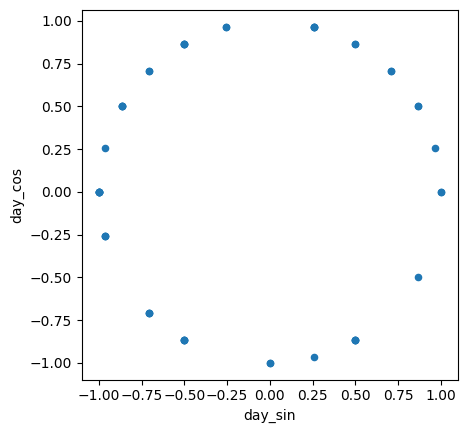

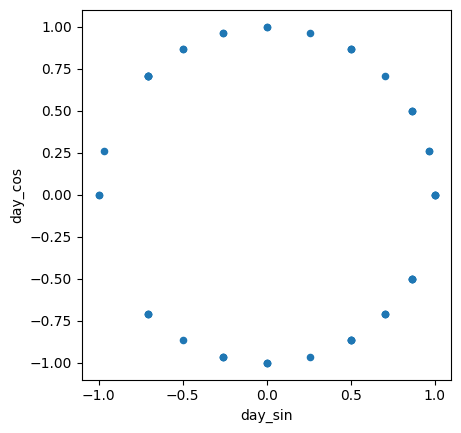

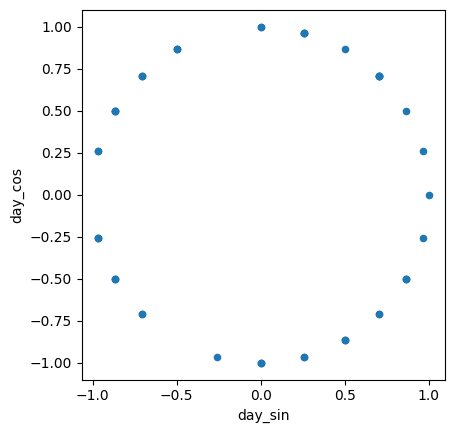

In [24]:
train=data_prep.dateTrans(train,"Date",True)
vald=data_prep.dateTrans(vald,"Date",True)
test=data_prep.dateTrans(test,"Date",True)

# Sclaing

- Robust Scaling was first applied to the SolarRadiation feature to reduce the impact of outliers (present in ~8.44% of the data). This transformation centers the feature on the median and scales it by the IQR. Afterward, a Min-Max normalization was applied to scale the robust-transformed data to the [0, 1] range for better compatibility with downstream models.

- Min-Max Scaling was used for Temp_C, Humidity, WindSpeed, and CloudCover to normalize these features into a 0–1 range, ensuring comparability and stabilizing model training.

- day_sin, day_cos are already bounded between -1 and 1 by design, representing cyclical daily patterns (no further scaling required).

- CountryCode (ranging from 0 to 23) is treated as a categorical variable and will be passed through an embedding layer in the model to capture country-specific patterns.

- is_holiday, is_weekend are binary features (0 or 1) and are used as-is.

In [28]:
minmax_feature=['Temp_C', 'Humidity', 'WindSpeed', 'CloudCover']
robust_feature=['SolarRadiation']
target_c='Value'
group_c='CountryLabel'

train_scaled,vald_scaled,test_scaled=data_prep.sclaing_per_country(train=train,vald=vald,test=test,
                                                         minmax_feature=minmax_feature,robust_feature=robust_feature,group_c=group_c,target_c=target_c)

In [ ]:
# train_scaled.to_csv("Data/training.csv", index=False)
# vald_scaled.to_csv("Data/valid.csv", index=False)
# test_scaled.to_csv("Data/testing.csv", index=False)
# map_label_country.to_csv("Data/country_map.csv", index=False)